In [15]:
BUFFER = 60

# Augmentation

In [2]:
import random
import numpy as np

def is_palm_static(data, hand='right', threshold=0.2):
    """
    data: [frames, 165]
    threshold: порог чувствительности (подбирается экспериментально)
    """
    # 1. Извлекаем только точки ладони (21 точка по 3 координаты = 63 значения)
    # По MediaPipe это индексы с 0 по 20 (если данные начинаются с руки)
    # В твоем случае срез 13*3:21*3 (если это индексы внутри 165)
    if hand=='left':
        palm_points = data[:, 13*3:34*3] 
    elif hand=='right':
        palm_points = data[:, 34*3:55*3] 
    else:
        return False
    
    # 2. Считаем, насколько сильно "гуляют" координаты во времени
    # axis=0 — считаем отклонение по кадрам для каждого признака
    std_dev = np.std(palm_points, axis=0)
    
    # 3. Находим среднее отклонение по всем точкам ладони
    avg_movement = np.mean(std_dev)
    
    # Если среднее движение меньше порога — ладонь статична
    return avg_movement < threshold


def invert(data):
    data_lh = data[:, 13*3:34*3].copy()
    data_rh = data[:, 34*3:55*3].copy()

    data[:, 13*3:34*3], data[:, 34*3:55*3] = data_rh, data_lh

    swaps = ((1, 2), (3, 4), (5, 6), (7, 8), (9, 10), (11, 12))
    for swap in swaps:
        d1 = data[:, swap[0]*3:(swap[0]+1)*3].copy()
        d2 = data[:, swap[1]*3:(swap[1]+1)*3].copy()
        data[:, swap[0]*3:(swap[0]+1)*3], data[:, swap[1]*3:(swap[1]+1)*3] = d2, d1

    data[:, 0:165:3] *= -1
    return data

def center_hadns(data):
    data_lh = data[:, 13*3:34*3].copy()
    data_rh = data[:, 34*3:55*3].copy()

    data[:, 13*3:34*3:3] = data_lh[:, 0::3] - data[:, 13*3, np.newaxis]
    data[:, 13*3+1:34*3:3] = data_lh[:, 1::3] - data[:, 13*3+1, np.newaxis]
    data[:, 13*3+2:34*3:3] = data_lh[:, 2::3] - data[:, 13*3+2, np.newaxis]

    data[:, 34*3:55*3:3] = data_rh[:, 0::3] - data[:, 34*3, np.newaxis]
    data[:, 34*3+1:55*3:3] = data_rh[:, 1::3] - data[:, 34*3+1, np.newaxis]
    data[:, 34*3+2:55*3:3] = data_rh[:, 2::3] - data[:, 34*3+2, np.newaxis]


    return data

def letter_augmentation(data, inv=False):
    if inv:
        data = invert(data)

    # scale
    scale = (random.random() - 0.5) * 0.25 + 1
    data[:, :] *= scale

    # rotate l hand
    data_hand = data[:, 13*3:34*3]

    center = data[:, 13*3:14*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    # rotate r hand
    data_hand = data[:, 34*3:55*3]

    center = data[:, 34*3:35*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    return data

In [3]:
import random


def augmentation(data, inv=False):
    if inv:
        data = invert(data)



    # data_lh = data[:, 13*3:34*3]
    # data_rh = data[:, 34*3:55*3]

    # off_l = data_lh[:, 2] - data[:, 7*3+2]
    # off_r = data_rh[:, 2] - data[:, 8*3+2]
    

    # data_lh[:, 2::3] -= off_l[:, np.newaxis]

    # data_rh[:, 2::3] -= off_r[:, np.newaxis]


    # # rotate left hand 1

    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 13*3, 34*3
    # center = data[:, 13*3 : (13+1)*3]  # [Frames, 3]
    # e_raw = data[:, (5)*3 : (6)*3] - data[:, (7)*3 : (8)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)

    # # rotate left hand 2

    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 13*3, 34*3
    # center = data[:, 13*3 : (13+1)*3]  # [Frames, 3]
    # e_raw = data[:, (13+5)*3 : (13+6)*3] - data[:, (13+17)*3 : (13+18)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)


    # # rotate right hand 1
    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 34*3, 55*3
    # center = data[:, 34*3 : (34+1)*3]  # [Frames, 3]
    # e_raw = data[:, (6)*3 : (7)*3] - data[:, (8)*3 : (9)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)

    # # rotate right hand 2
    # theta = np.radians((np.random.random() - 0.5) * 90)
    # c, s = np.cos(theta), np.sin(theta)

    # h_start, h_end = 34*3, 55*3
    # center = data[:, 34*3 : (34+1)*3]  # [Frames, 3]
    # e_raw = data[:, (34+5)*3 : (34+6)*3] - data[:, (34+17)*3 : (34+18)*3]  # [Frames, 3]

    # norm = np.linalg.norm(e_raw, axis=1, keepdims=True) + 1e-9
    # e = e_raw / norm  # [Frames, 3]

    # points = data[:, h_start:h_end].reshape(-1, 21, 3)

    # v = points - center[:, np.newaxis, :]

    # k_cross_v = np.cross(e[:, np.newaxis, :], v, axis=-1)
    # k_dot_v = np.einsum('fi,fji->fj', e, v) # [Frames, 21]
    # k_k_dot_v = k_dot_v[:, :, np.newaxis] * e[:, np.newaxis, :] # [Frames, 21, 3]
    # v_rot = v * c + k_cross_v * s + k_k_dot_v * (1 - c)

    # data[:, h_start:h_end] = (v_rot + center[:, np.newaxis, :]).reshape(data.shape[0], -1)
    

    # rotate l hand
    data_hand = data[:, 13*3:34*3]

    center = data[:, 13*3:14*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    # rotate r hand
    data_hand = data[:, 34*3:55*3]

    center = data[:, 34*3:35*3].copy()

    x = data_hand[:, 0::3] - center[:, 0, np.newaxis]
    y = data_hand[:, 1::3] - center[:, 1, np.newaxis]
    z = data_hand[:, 2::3] - center[:, 2, np.newaxis]
    
    theta = np.radians((random.random()-0.5)*20) # rotate z
    c, s = np.cos(theta), np.sin(theta)
    temp1_x = c * x - s * y
    temp1_y = s * x + c * y
    temp1_z = z

    theta = np.radians((random.random()-0.5)*20) # rotate x
    c, s = np.cos(theta), np.sin(theta)
    temp2_x = temp1_x
    temp2_y = c * temp1_y - s * temp1_z
    temp2_z = s * temp1_y + c * temp1_z

    theta = np.radians((random.random()-0.5)*20) # rotate y
    c, s = np.cos(theta), np.sin(theta)
    temp3_x = c * temp2_x + s * temp2_z
    temp3_y = temp2_y
    temp3_z = - s * temp2_x + c * temp2_z

    data_hand[:, 0::3], data_hand[:, 1::3], data_hand[:, 2::3] = temp3_x, temp3_y, temp3_z

    data_hand[:, 0::3] += center[:, 0, np.newaxis]
    data_hand[:, 1::3] += center[:, 1, np.newaxis]
    data_hand[:, 2::3] += center[:, 2, np.newaxis]  


    # # move hands
    # move = [(random.random() - 0.5) * 0.5 for i in range(3)]

    # data_hands[:, 0::3] += move[0]
    # data_hands[:, 1::3] += move[1]
    # # data_hands[:, 2::3] += move[2]

#     # # cutoff
#     # c = random.random()
#     # if c > 0.5:
#     #     c *= BUFFER
#     #     for i in range(BUFFER):
#     #         if i > c:
#     #             data[i] = data[i-1]


    # move
    move = [(random.random() - 0.5) * 0.3 for i in range(2)]

    data[:, 0:165:3] += move[0]
    data[:, 1:165:3] += move[1]
    
    # scale
    scale = (random.random() - 0.5) * 0.25 + 1
    data[:, :] *= scale

    # rotate
    new_ind = random.randint(0, 5)
    x = data[:, 0:165:3]
    y = data[:, 1:165:3]
    z = data[:, 2:165:3]

    theta = np.radians(random.random()*30)
    if new_ind%2==0:
        theta *= -1

    c, s = np.cos(theta), np.sin(theta)

    if new_ind//2 == 0: # rotate x
        new_y = c * y - s * z
        new_z = s * y + c * z
        data[:, 1:165:3], data[:, 2:165:3] = new_y, new_z
    if new_ind//2 == 1: # rotate y
        new_x = c * x + s * z
        new_z = - s * x + c * z
        data[:, 0:165:3], data[:, 2:165:3] = new_x, new_z
    if new_ind//2 == 2: # rotate z
        new_x = c * x - s * y
        new_y = s * x + c * y
        data[:, 0:165:3], data[:, 1:165:3] = new_x, new_y

    # speed
    ind = 0
    offset = int((random.random() - 0.5) * 20)
    if abs(offset) > 1:
        data_new = data.copy()
        for i in range(BUFFER):
            if ind==BUFFER:
                break
            if i%offset==0:
                if offset > 0:
                    data_new[ind] = data_new[ind-1]
                    ind += 1
                    if ind==BUFFER:
                        break
                    data_new[ind] = data[i]
                    ind += 1
                else:
                    continue
            else:
                data_new[ind] = data[i]
                ind += 1

        while ind<BUFFER:
            data_new[ind] = data_new[ind-1]
            ind += 1

        data = data_new


    # if is_palm_static(data, 'left'):
    #     r = random.random()
    #     if r > 0.6:
    #         data[:, 13*3:34*3] = np.zeros(data[:, 13*3:34*3].shape)

    # if is_palm_static(data, 'right'):
    #     r = random.random()
    #     if r > 0.6:
    #         data[:, 34*3:55*3] = np.zeros(data[:, 34*3:55*3].shape)

    # r = random.random()
    # if r > 0.5:
    #     data = data[:-1, :]

    
    return data

In [3]:
import numpy as np

dataset = np.memmap(f"tracking/{BUFFER}/full_dataset_test.bin", dtype='float32', mode='r', shape=(len(test_labels), BUFFER, 165))

In [234]:
a = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
a.reshape(4, 3)

array([[ 1,  2,  3],
       [ 4,  5,  6],
       [ 7,  8,  9],
       [10, 11, 12]])

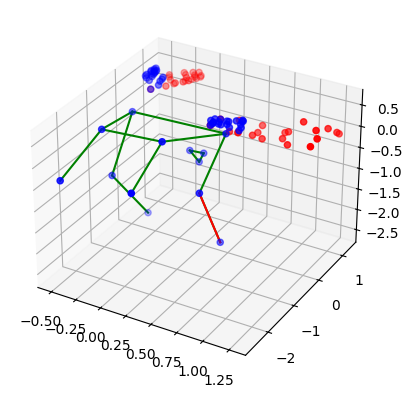

In [29]:
from matplotlib import pyplot as plt

# d = augmentation(dataset[1362].copy())[0].reshape(55, 3)
d = dataset[1400][20].reshape(55, 3)
fig  = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.axis('equal')

ax.scatter3D(d[:, 0], -d[:, 1], d[:, 2], c='blue')


conn = ((0,1), (1,2), (0,2), (3,4), (5,3), (4,6), 
        (4,10), (9, 10), (3,9), (12,10), (11,9), 
        (6,8), (5,7))

for elem in conn:
    ax.plot3D( [d[elem[0]][0], d[elem[1]][0]],
            [-d[elem[0]][1], -d[elem[1]][1]],
            [d[elem[0]][2], d[elem[1]][2]], 'green')
    
ax.plot3D([d[5][0], d[7][0]], [-d[5][1], -d[7][1]], [d[5][2], d[7][2]], color='red')

d = letter_augmentation(dataset[1400].copy())[20].reshape(55, 3)
# d = data[20].reshape(55, 3)

ax.scatter3D(d[13:55, 0], -d[13:55, 1], d[13:55, 2], c='red')


# conn = ((0,1), (1,2), (0,2), (3,4), (5,3), (4,6), 
#         (4,10), (9, 10), (3,9), (12,10), (11,9), 
#         (6,8), (5,7))

# for elem in conn:
#     ax.plot3D( [d[elem[0]][0], d[elem[1]][0]],
#             [-d[elem[0]][1], -d[elem[1]][1]],
#             [d[elem[0]][2], d[elem[1]][2]], 'green')

plt.show()

In [248]:
%timeit augmentation(dataset[22].copy())

527 μs ± 3.57 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


# Tensorflow

In [4]:
import tensorflow as tf
import keras
import os

print(f"Версия TensorFlow: {tf.__version__}")
print(f"Построен с поддержкой CUDA: {tf.test.is_built_with_cuda()}")
print(f"Доступные GPU: {tf.config.list_physical_devices('GPU')}")

# Проверка библиотек в путях системы
cuda_path = os.environ.get('CUDA_PATH')
print(f"Путь к CUDA в системе: {cuda_path}")

2026-04-14 14:49:50.896965: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 14:49:51.185215: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776167391.301627    1487 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776167391.333753    1487 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776167391.589364    1487 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Версия TensorFlow: 2.19.1
Построен с поддержкой CUDA: True
Доступные GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Путь к CUDA в системе: None


In [5]:
@keras.saving.register_keras_serializable()
class SparseFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma
        self.alpha = alpha

    def call(self, y_true, y_pred):
        # 1. Считаем стандартную кросс-энтропию
        y_true = tf.cast(y_true, tf.int32)
        scce = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)
        
        # 2. Получаем вероятность предсказанного (правильного) класса
        # Мы используем gather_nd, чтобы вытащить p_t для каждого примера
        batch_size = tf.shape(y_pred)[0]
        range_idx = tf.range(batch_size)
        indices = tf.stack([range_idx, tf.reshape(y_true, [-1])], axis=1)
        p_t = tf.gather_nd(y_pred, indices)
        
        # 3. Формула Focal Loss: (1 - p_t)^gamma * log(p_t)
        focal_modulation = tf.pow(1.0 - p_t, self.gamma)
        loss = focal_modulation * scce
        
        return tf.reduce_mean(loss)

In [6]:
import numpy as np
from keras.utils import Sequence
from datetime import datetime as dt
 

class GestureDataGenerator(Sequence):
    def __init__(self, dataset_path, labels, embedding_dict, batch_size=32, shuffle=True, aug=False, aug_func=None, invert=False, num_classes=1001, **kwargs):
        self.dataset = np.memmap(dataset_path, dtype='float32', mode='r', shape=(len(labels), BUFFER, 165))
        self.labels = labels
        self.embedding_dict = embedding_dict
        self.aug_func = aug_func
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.aug = aug
        self.invert = invert
        self.num_classes = num_classes
        self.on_epoch_end()
        super().__init__(**kwargs)

    def __len__(self):
        return int(np.ceil(len(self.labels) / self.batch_size))

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.labels))
        if self.shuffle:
            np.random.shuffle(self.indexes)
        

    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size : (index + 1) * self.batch_size].copy()
        curr_batch_size = len(indexes)
        arr_size = curr_batch_size

        if self.aug:
            arr_size *= 2

        X = np.empty(shape=(arr_size, BUFFER, 165))   
        y_class = np.zeros((arr_size, self.num_classes), dtype='float32')
        
        for i, ind in enumerate(indexes):

            label = self.labels[ind]   

            if self.aug:
                d = self.dataset[ind].copy()
                x = self.aug_func(d), self.aug_func(d, inv=True)
                for j in range(len(x)):
                    X[i+j*curr_batch_size] = x[j]
                            
                    y_class[i+j*curr_batch_size][self.embedding_dict[label]] = 1

            else:
                d = self.dataset[ind].copy()
                x = d
                if self.invert:
                    x = invert(x)
                X[i] = x
                y_class[i][self.embedding_dict[label]] = 1



        return X, y_class


# Model letters

## Data

In [7]:
letters = []
with open("dataset/letters.txt", 'r') as f:
    letters = [w.replace("\n", "") for w in f.readlines()]

letters

['А',
 'Б',
 'В',
 'Г',
 'Д',
 'Е',
 'Ё',
 'Ж',
 'З',
 'И',
 'Й',
 'К',
 'Л',
 'М',
 'Н',
 'О',
 'П',
 'Р',
 'С',
 'Т',
 'У',
 'Ф',
 'Х',
 'Ц',
 'Ч',
 'Ш',
 'Щ',
 'Ъ',
 'Ы',
 'Ь',
 'Э',
 'Ю',
 'Я']

In [17]:
import pandas as pd
import numpy as np

path = "./dataset/"

df = pd.read_csv(path+f"annotations{BUFFER}.csv", index_col=0)

n_train_letters = n_test_letters = 0

train_data_letters = []
test_data_letters = []

for i in range(len(df)):
    max_offset = max(int(df.loc[i, "new_length"])-BUFFER+1, 1)
    if df.loc[i, "text"] not in letters:
        continue
    for offset in range(0, max_offset, max(max_offset, 5) // 5):
        if df.loc[i, "train"]:
            train_data_letters.append([f"tracking/{BUFFER}/train/{df.loc[i, 'attachment_id']}.npy", df.loc[i, "text"], offset])
        else:
            test_data_letters.append([f"tracking/{BUFFER}/test/{df.loc[i, 'attachment_id']}.npy", df.loc[i, "text"], offset])



train_data_df_letters = pd.DataFrame(data=train_data_letters, 
                             columns=['path', 'label', 'offset'])
test_data_df_letters = pd.DataFrame(data=test_data_letters,
                            columns=['path', 'label', 'offset'])


train_paths_letters = list(train_data_df_letters["path"])
train_labels_letters = list(train_data_df_letters["label"])
train_offsets_letters = list(train_data_df_letters["offset"])

test_paths_letters = list(test_data_df_letters["path"])
test_labels_letters = list(test_data_df_letters["label"])
test_offsets_letters = list(test_data_df_letters["offset"])


embedding_df = pd.read_csv("models/embedding/word_vectors.csv", encoding="UTF-8", index_col=0)
uniq_words = df["text"].unique()
embedding_matrix = embedding_df.values.astype('float32')
embedding_dict_letters = {}
embedding_dict_reverse_letters = {}
for i, word in enumerate(letters):
    embedding_dict_letters[word] = i
    embedding_dict_reverse_letters[i] = word


In [9]:
train_data_df_letters["label"].unique().shape

(33,)

In [11]:
import numpy as np
from tqdm import tqdm

N_SAMPLES = len(train_paths_letters)
shape = (N_SAMPLES, BUFFER, 165)

fp = np.memmap(f'tracking/{BUFFER}/train_letters.bin', dtype='float32', mode='w+', shape=shape)

for i, path in tqdm(enumerate(train_paths_letters)):
    data_all = np.load(path)
    fp[i] = data_all[train_offsets_letters[i]].reshape(BUFFER, 165)
    
fp.flush()

772it [00:00, 1305.80it/s]


In [12]:
N_SAMPLES = len(test_paths_letters) 
shape = (N_SAMPLES, BUFFER, 165)

fp = np.memmap(f'tracking/{BUFFER}/test_letters.bin', dtype='float32', mode='w+', shape=shape)

for i, path in tqdm(enumerate(test_paths_letters)):
    data_all = np.load(path)
    fp[i] = data_all[test_offsets_letters[i]].reshape(BUFFER, 165)
    
fp.flush()

302it [00:00, 1652.98it/s]


## Model

In [10]:
import tensorflow as tf
from keras import layers, models, regularizers


@keras.saving.register_keras_serializable()
def new_inputs(x):
    return x[:, :, 13*3:]


@keras.saving.register_keras_serializable()
class GlobalMinPool1D(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.keras.backend.min(inputs, axis=1)
    

@keras.saving.register_keras_serializable()
def std(x):
    return tf.math.reduce_std(x, axis=1)
    

@keras.saving.register_keras_serializable()
def centralize_hands(x):
    center_left = x[:, :, 13*3:14*3]  
    center_right = x[:, :, 34*3:35*3] 

    scale_pt_left = x[:, :, 13*3+27 : 13*3+30]
    scale_pt_right = x[:, :, 34*3+27 : 34*3+30]
    dist_left = tf.norm(scale_pt_left - center_left, axis=-1, keepdims=True) + 1e-8
    dist_right = tf.norm(scale_pt_right - center_right, axis=-1, keepdims=True) + 1e-8

    parts = []
    
    parts.append(x[:, :, :13*3])
    
    left_hand_centered = x[:, :, 13*3:34*3] - tf.tile(center_left, [1, 1, 21])
    left_hand_scaled = left_hand_centered / tf.tile(dist_left, [1, 1, 63])
    parts.append(left_hand_scaled)

    right_hand_centered = x[:, :, 34*3:55*3] - tf.tile(center_right, [1, 1, 21])
    right_hand_scaled = right_hand_centered / tf.tile(dist_right, [1, 1, 63])
    parts.append(right_hand_scaled)
        
    return tf.concat(parts, axis=-1)


def build_dense_model():
    inputs = layers.Input(shape=(BUFFER, 165))

    x = layers.Lambda(centralize_hands)(inputs)
    x = layers.Lambda(new_inputs)(x)

    # x = layers.BatchNormalization()(x)

    avg_pool = layers.GlobalAveragePooling1D()(x) 
    max_pool = layers.GlobalMaxPooling1D()(x) 
    min_pool = GlobalMinPool1D()(x)
    std_pool = layers.Lambda(std)(x)

    x = layers.Concatenate()([avg_pool, std_pool, max_pool, min_pool])

    # x = layers.Flatten()(x)

    x = layers.Dense(64, activation='elu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.4)(x)

    outputs = layers.Dense(33, activation='softmax')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.0),
        metrics=['accuracy']
    )
    
    return model

In [18]:
train_gen_letters = GestureDataGenerator(f"tracking/{BUFFER}/train_letters.bin", 
                                         train_labels_letters, embedding_dict_letters, 
                                         batch_size=1024, shuffle=True, num_classes=33,
                                         aug=True, aug_func=augmentation,
                                         use_multiprocessing=True, workers=6)
test_gen_letters = GestureDataGenerator(f"tracking/{BUFFER}/test_letters.bin", 
                                        test_labels_letters, embedding_dict_letters, 
                                        batch_size=1024, shuffle=False, num_classes=33,
                                        use_multiprocessing=True, workers=6)

In [100]:
%timeit train_gen_letters[22]

1.59 μs ± 6.52 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [101]:
train_gen_letters.__len__()

3

In [102]:
model = build_dense_model()
model.summary()

Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 40, 165)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 40, 165)   │          0 │ input_layer_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 40, 126)   │          0 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 126)       │          0 │ lambda_19[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 126)       │          0 │ lambda_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 126)       │          0 │ lambda_19[0][0]   │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_min_pool1d_6 │ (None, 126)       │          0 │ lambda_19[0][0]   │
│ (GlobalMinPool1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_6       │ (None, 504)       │          0 │ global_average_p… │
│ (Concatenate)       │                   │            │ lambda_20[0][0],  │
│                     │                   │            │ global_max_pooli… │
│                     │                   │            │ global_min_pool1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 64)        │     32,320 │ concatenate_6[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64)        │        256 │ dense_12[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 64)        │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_13 (Dense)    │ (None, 33)        │      2,145 │ dropout_5[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 34,721 (135.63 KB)

 Trainable params: 34,593 (135.13 KB)

 Non-trainable params: 128 (512.00 B)

In [103]:
with tf.device('/GPU:0'):
    model.fit(
        train_gen_letters,
        validation_data=test_gen_letters,
        epochs=300,
        callbacks=[
            tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=2)
        ],
    )

Epoch 1/300
1/3 ━━━━━━━━━━━━━━━━━━━━ 6s 3s/step - accuracy: 0.0215 - loss: 4.5636

2026-04-14 14:25:54.390461: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'input_concatenate_fusion_1', 12 bytes spill stores, 12 bytes spill loads



3/3 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.0255 - loss: 4.3828 - val_accuracy: 0.0281 - val_loss: 3.5196 - learning_rate: 0.0010
Epoch 2/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 438ms/step - accuracy: 0.0410 - loss: 4.0010 - val_accuracy: 0.0450 - val_loss: 3.4029 - learning_rate: 0.0010
Epoch 3/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 386ms/step - accuracy: 0.0615 - loss: 3.7296 - val_accuracy: 0.0802 - val_loss: 3.3280 - learning_rate: 0.0010
Epoch 4/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.0728 - loss: 3.5932 - val_accuracy: 0.0914 - val_loss: 3.2747 - learning_rate: 0.0010
Epoch 5/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step - accuracy: 0.0870 - loss: 3.5330 - val_accuracy: 0.1069 - val_loss: 3.2299 - learning_rate: 0.0010
Epoch 6/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 935ms/step - accuracy: 0.0995 - loss: 3.4073 - val_accuracy: 0.1364 - val_loss: 3.1915 - learning_rate: 0.0010
Epoch 7/300
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 475ms/step - accuracy: 0.1051 - loss: 3.3690 - val_accuracy: 0.1139 - va

In [104]:
import joblib

joblib.dump(model, "models/recognizing/letters.joblib")

['models/recognizing/letters-40-2.joblib']

## Test

In [37]:
import joblib

loaded_model = joblib.load("models/recognizing/letters-60-7.joblib")

In [105]:
loaded_model = model

In [ ]:
loaded_model.summary()

In [38]:
from tqdm import tqdm
from sklearn.metrics import accuracy_score, classification_report

test_paths_letters = list(test_data_df_letters["path"])
test_labels_letters = list(test_data_df_letters["label"])
test_offsets_letters = list(test_data_df_letters["offset"])



predictions_letters = loaded_model.predict(test_gen_letters)



def accuracy(predictions_letters, min_confidence=0.5):
    labels_class_pred = []
    new_test_labels_letters = []
    for i in range(len(test_labels_letters)):
        max_prop = -1
        class_pred = 0
        for j in range(len(predictions_letters[i])):
            prop = max(predictions_letters[i][j], 0)
            if prop > max_prop:
                max_prop = prop
                class_pred = j

        if max_prop < min_confidence:
            class_pred = -1
            # new_test_labels_letters.append("default")
            # labels_class_pred.append(embedding_dict_reverse_letters.get(class_pred, "default"))
        else:
            new_test_labels_letters.append(test_labels_letters[i])
            labels_class_pred.append(embedding_dict_reverse_letters.get(class_pred, "default"))

    return accuracy_score(new_test_labels_letters, labels_class_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 877ms/step


In [39]:
print(accuracy(predictions_letters, 0))
print(accuracy(predictions_letters, 0.25))
print(accuracy(predictions_letters, 0.5))
print(accuracy(predictions_letters, 0.75))

0.7284768211920529
0.7615658362989324
0.8324873096446701
0.9230769230769231
